In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from ssqueezepy import ssq_stft

In [20]:
def load_pm6_data(filepath):
    """
    Загрузка данных из PM6. 
    Предполагается, что данные разделены пробелами/табуляцией.
    """
    # Названия колонок согласно спецификации УРАН-4
    columns = [
        'MJD', 
        'P1_20A', 'M1_20A', 
        'P2_20B', 'M2_20B', 
        'P3_25A', 'M3_25A', 
        'P4_25B', 'M4_25B'
    ]
    
    # Чтение данных. sep='\s+' означает любой пробел/табуляцию
    df = pd.read_csv(filepath, sep='\s+', names=columns, header=30, encoding='cp1251')
    
    # Перевод юлианской даты (MJD) в относительные секунды от начала записи
    # Шаг 1 секунда, поэтому можно просто использовать индекс как секунды,
    # но правильнее считать дельту времени.
    mjd_start = df['MJD'].iloc[0]
    df['Time_sec'] = (df['MJD'] - mjd_start) * 86400.0 
    
    return df

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Двунаправленный фильтр Баттерворта для устранения фазовых сдвигов.
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def main():
    # 1. ЗАГРУЗКА ДАННЫХ
    # Укажите путь к вашему файлу PM6
    file_path = "Data/04012013me.PM6" 
    
    try:
        df = load_pm6_data(file_path)
    except FileNotFoundError:
        print(f"Файл {file_path} не найден. Для демонстрации сгенерирован синтетический сигнал.")
        # [Inference] Генерация синтетического сигнала для проверки работоспособности кода без PM6 файла
        t = np.arange(0, 3600, 1) # 1 час данных, шаг 1 секунда
        signal_base = np.sin(2 * np.pi * t / 1800) * 100 # Медленный тренд прохождения источника
        ionospheric_scintillations = np.sin(2 * np.pi * t / 50) * 20 # Мерцания с периодом 50 сек
        noise = np.random.normal(0, 5, len(t))
        raw_signal = signal_base + ionospheric_scintillations + noise
        time_sec = t
    else:
        # Берем данные канала 20 МГц, поляризация А (сумма)
        raw_signal = df['P1_20A'].values
        time_sec = df['Time_sec'].values

    # 2. ФИЛЬТРАЦИЯ (Малые пузырьки плазмы: 5 - 150 секунд)
    fs = 1.0  # Частота дискретизации (1 Гц, так как шаг 1 секунда)
    lowcut = 1.0 / 150.0  # ~0.0067 Гц
    highcut = 1.0 / 5.0   # 0.2 Гц
    
    filtered_signal = bandpass_filter(raw_signal, lowcut, highcut, fs, order=4)

    # 3. СПЕКТРОГРАММА (FSST - Synchrosqueezing)
    # Вычисляем Synchrosqueezed STFT
    Tx, _, _, _ = ssq_stft(filtered_signal, fs=fs)
    
    # Берем модуль комплекснозначного результата
    Tx_abs = np.abs(Tx)

    # 4. ВИЗУАЛИЗАЦИЯ
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # Сырые данные
    axes[0].plot(time_sec, raw_signal, color='blue', linewidth=0.8)
    axes[0].set_title('Сырые данные радиотелескопа (Полная мощность)')
    axes[0].set_ylabel('ADC Unit')
    axes[0].grid(True, alpha=0.5)

    # Отфильтрованные данные (Ионосферные мерцания)
    axes[1].plot(time_sec, filtered_signal, color='green', linewidth=1)
    axes[1].set_title('Выделенные ионосферные мерцания (Полоса 5 - 150 сек)')
    axes[1].set_ylabel('Амплитуда')
    axes[1].grid(True, alpha=0.5)

    # FSST Спектрограмма
    # Ограничиваем ось Y максимальной частотой фильтра (0.2 Гц) для наглядности
    im = axes[2].imshow(Tx_abs, aspect='auto', cmap='jet', 
                        extent=[time_sec[0], time_sec[-1], fs/2, 0])
    axes[2].set_ylim(lowcut, highcut) # Фокусируемся на интересующей полосе частот
    axes[2].invert_yaxis()
    axes[2].set_title('FSST Спектрограмма мерцаний (Synchrosqueezing)')
    axes[2].set_ylabel('Частота (Гц)')
    axes[2].set_xlabel('Время (секунды)')
    
    plt.tight_layout()
    plt.show()

In [16]:
load_pm6_data("Data/04012013me.PM6")

,MJD,P1_20A,M1_20A,P2_20B,M2_20B,P3_25A,M3_25A,P4_25B,M4_25B,Time_sec
0,41278.742225,6.708,6.645,17.01,16.90,8.021,7.960,8.112,8.188,0.0000
1,41278.742238,6.649,6.611,17.01,16.89,8.006,7.942,8.134,8.126,1.1232
2,41278.742251,6.631,6.593,16.94,16.92,7.991,7.982,8.102,8.062,2.2464
3,41278.742263,6.589,6.656,16.97,16.94,7.981,7.994,8.085,8.096,3.2832
4,41278.742276,6.605,6.647,16.86,16.97,7.939,8.014,8.079,8.089,4.4064
...,...,...,...,...,...,...,...,...,...,...
506064,41285.924225,6.494,6.478,12.57,12.54,6.171,6.193,5.814,5.870,620524.8000
506065,41285.924238,6.463,6.496,12.56,12.54,6.213,6.218,5.836,5.881,620525.9232
506066,41285.924250,6.506,6.516,12.56,12.59,6.213,6.191,5.860,5.860,620526.9600
506067,41285.924269,6.501,6.534,12.57,12.56,6.221,6.221,5.827,5.811,620528.6016


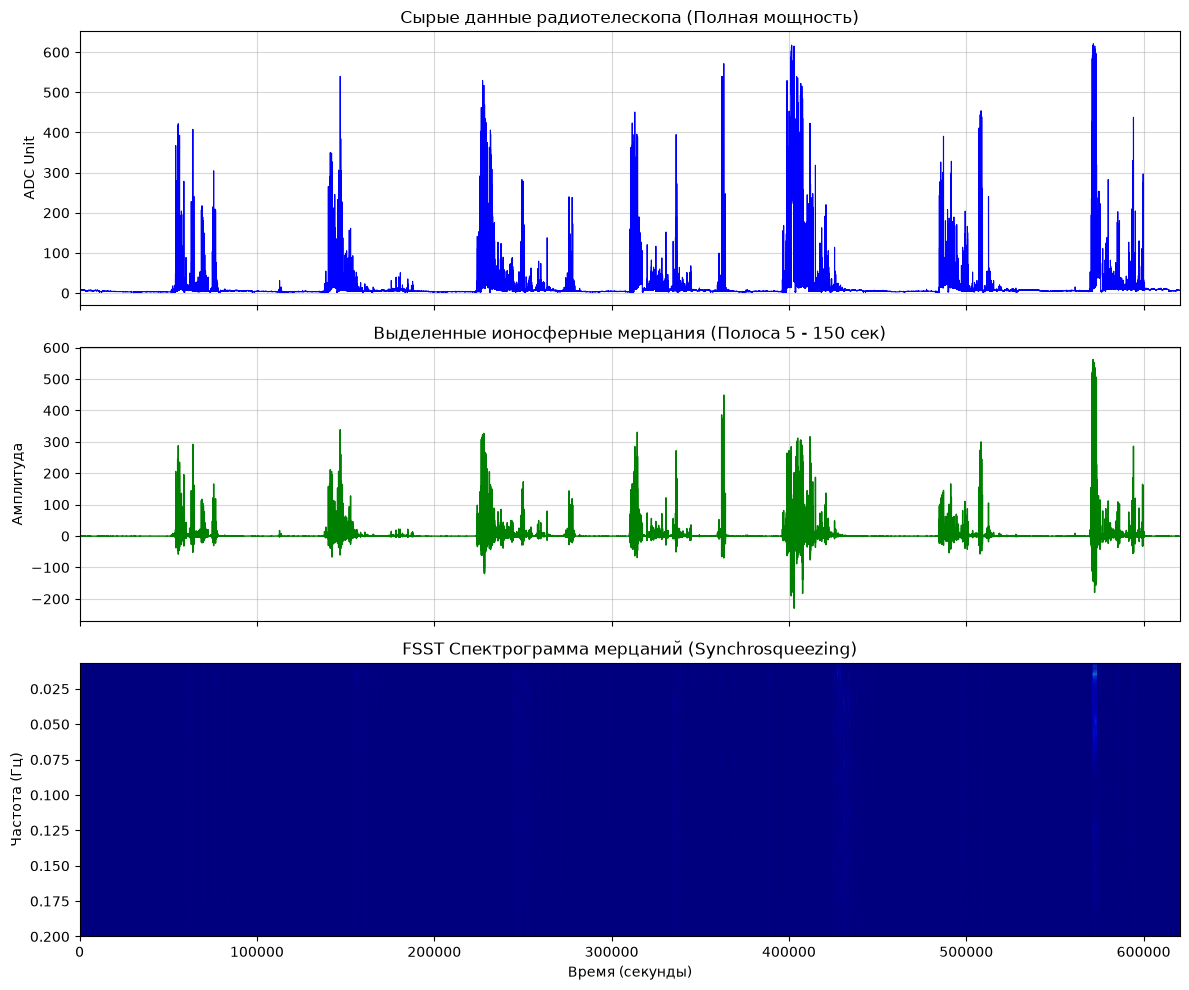

In [21]:
main()

In [9]:
import pandas as pd

def parse_regi_file(filepath):
    """
    Парсинг лог-файла таймингов УРАН-4.
    """
    events = []
    
    # Читаем файл построчно
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        
        # Пропускаем пустые строки или строки без тире (например, заголовок с датой)
        if not line or '-' not in line:
            continue
            
        # Разбиваем строку по любым пробелам
        parts = line.split()
        
        # Проверяем, что это валидная строка с таймингом
        if len(parts) >= 8 and parts[1] == '-':
            start_time = parts[0]
            # Убираем скобки у времени конца
            end_time = parts[2].replace('(', '').replace(')', '')
            # Имя всегда находится в самом конце строки
            name = parts[-1]
            
            events.append({
                'Start_Time': start_time,
                'End_Time': end_time,
                'Target_Name': name
            })

    # Превращаем результат в удобный DataFrame
    return pd.DataFrame(events)

# Проверка работы
df_logs = parse_regi_file("Data\\regi4-1-2013.txt")
print(df_logs.head(10))


  Start_Time End_Time Target_Name
0      16:53    17:10       3C461
1      17:53    18:10       3C461
2      18:53    19:10       3C461
3      19:53    20:10       3C461
4      20:53    21:10  calibrovka
5      20:58    21:15     3Czenit
6      21:13    21:30  calibrovka
7      21:18    21:35       3C144
8      21:58    22:15       3C144
9      22:38    22:55       3C144


In [ ]:
import pandas as pd

def parse_regi_file(filepath):
    """
    Читает лог таймингов и оставляет только Время и Имя источника/калибровки.
    """
    events = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            
            # Проверяем, что строка похожа на запись времени (есть тире)
            if len(parts) >= 4 and parts[1] == '-':
                try:
                    start_time = parts[0]
                    # Убираем скобки вокруг времени окончания
                    end_time = parts[2].replace('(', '').replace(')', '')
                    # Имя всегда гарантированно последнее в строке
                    name = parts[-1]
                    
                    events.append({
                        'Start_Time': start_time,
                        'End_Time': end_time,
                        'Target_Name': name
                    })
                except IndexError:
                    continue # Пропускаем битые строки
                    
    return pd.DataFrame(events)


In [2]:
# Проверка:
df_logs = parse_regi_file("Data/regi4-1-2013.txt")
print(df_logs[df_logs['Target_Name'] == 'calibrovka'])

   Start_Time End_Time Target_Name
4       20:53    21:10  calibrovka
6       21:13    21:30  calibrovka
16       3:14    03:35  calibrovka
18       3:24    03:45  calibrovka
29       10:9    10:30  calibrovka
